In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# This script targets the Python client API version 2.0.0 and later
import labkey
from labkey.api_wrapper import APIWrapper

In [25]:
# desired isolates
post = pd.read_csv(
    "/networks/vtn/lab/SDMC_labscience/studies/HVTN/HVTN703_704/analysis/nAb/data/selectedpubids_postWk80.csv",
)
wk80 = pd.read_csv(
    "/networks/vtn/lab/SDMC_labscience/studies/HVTN/HVTN703_704/analysis/nAb/data/selectedpubids_wk80.csv",
)

post['cat'] = 'post_wk80'
wk80['cat'] = 'wk80'
df = pd.concat([wk80, post])

In [26]:
# merge on ptids
pubids703 = pd.read_sas(
    "/trials/vaccine/p703/analysis/adata/enrolled.sas7bdat"
)
pubids704 = pd.read_sas(
    "/trials/vaccine/p704/analysis/adata/enrolled.sas7bdat"
)

pubids703.pub_id = pubids703.pub_id.astype(str)
pubids704.pub_id = pubids704.pub_id.astype(str)
pubids = pd.concat([pubids703, pubids704])
df = df.merge(pubids[['pub_id','ptid']], how='left')

In [27]:
df

,pub_id,protocol,tx,gmt80ls,phenotype,cat,ptid
0,703-0520,HVTN 703,T1,0.427583,sensitive,wk80,281301216.0
1,703-0537,HVTN 703,C3,0.256997,sensitive,wk80,586300365.0
2,703-0566,HVTN 703,C3,10.614738,resistant,wk80,278300513.0
3,703-1034,HVTN 703,T2,22.798096,resistant,wk80,513300309.0
4,704-1328,HVTN 704,T2,9.726259,resistant,wk80,605401485.0
5,704-1535,HVTN 704,C3,0.304237,sensitive,wk80,269400500.0
6,704-1747,HVTN 704,T2,0.403671,sensitive,wk80,605401988.0
7,704-3008,HVTN 704,C3,9.891538,resistant,wk80,285402709.0
8,703-1764,HVTN 703,C3,0.803832,sensitive,post_wk80,276301273.0
9,703-1453,HVTN 703,T2,13.127006,resistant,post_wk80,277300631.0


In [33]:
# merge on isolate names
bids704 = pd.read_csv("/trials/vaccine/p704/s670/qdata/VSEQ/breakthrough/HVTN704_VSEQ_20211004.txt", sep="\t")
bids703 = pd.read_csv("/trials/vaccine/p703/s573/qdata/VSEQ/breakthrough_20221006/HVTN703_VSEQ_20221006.txt", sep="\t")
bids = pd.concat([bids703, bids704])

# bids.PTID = bids.PTID.astype(int)
# df.ptid = df.ptid.astype(int)
df = df.merge(bids[['PTID','PLASMID_NAME']], left_on='ptid', right_on='PTID', how='left')

In [6]:
# might end up pulling data from these instead of atlas
dat703 = pd.read_csv(
    "/trials/vaccine/p703/s573/qdata/Dilution_level_nab_data/VTN703_NAB_dilution_level_data_Breakthrough_20200928_E002_A.tsv",
    sep="\t"
)

dat704 = pd.read_csv(
    "/trials/vaccine/p704/s670/qdata/Dilution_level_nab_data/VTN704_NAB_dilution_level_data_Breakthrough_20201003_E001_A.txt",
    sep="\t"
)

dat = pd.concat([dat703, dat704])

In [140]:
# column_rename = {
#     'Run/VirusName':'virus_name',
#     'SpecimenLsid/Property/MAbLot':'mablot',
#     'ParticipantId':'mab',
#     'DilutionData/MinDilution':'min_dilution', #Min dilution 
#     'DilutionData/Dilution':'concentration',
#     'DilutionData/PercentNeutralization':'pct_neutralization',
#     'Run/Name':'run_name',
#     'Run/VirusID':'virus_id',
#     'SpecimenLsid/Property/specimenid':'guspec',
#     'SpecimenLsid/Property/ConcUnits':'concentration_units',
#     'SpecimenLsid/Property/Method':'method',
#     'Run/FileID':'run_fileid',
#     'Run/VirusControlAggregates/AvgValue': 'virus_control_mean',
#     'Run/VirusControlAggregates/StdDevValue': 'virus_control_std',
#     'DilutionData/Mean': 'sample_rlu_mean',
#     'DilutionData/StdDev': 'sample_rlu_std',
#     'Run/CellControlAggregates/AvgValue': 'cell_control_mean',
#     'Run/CellControlAggregates/StdDevValue': 'cell_control_std',
#     'FitParameters': 'Fit Parameters',
#     'FitError': 'Fit Error',
#     'DilutionData/ReplicateName':'replicate_name',
#     'Run/PlateNumber':'plate_number',
#     'Run/Experiment_Date':'experiment_date',
# }

In [7]:
atlas_col_rename = {
    'Run/VirusNameOther': 'isolate',
    'DilutionData/Dilution': 'dilution',
    'DilutionData/PercentNeutralization': 'pct_neutralization',
    'FitParameters': 'fitparams',
    'Cutoff50/IC': 'ic50',
    'Cutoff80/IC': 'ic80',
    'ParticipantId':'mab',
}

In [8]:
# pull dilution level data + fits from atlas
# 703
api = APIWrapper("atlas.scharp.org", "HVTN/Labs/Mkhize/NAb assays approved/703_breakthrough_mAbs", use_ssl=True)

my_results = api.query.select_rows(
    schema_name="study",
    query_name="NAb HVTN - Morris",
    columns=','.join(atlas_col_rename.keys()),
)
atlas703 = pd.DataFrame(my_results['rows'])
atlas703 = atlas703[['Run/VirusNameOther','DilutionData/Dilution','DilutionData/PercentNeutralization','FitParameters','Cutoff50/IC','Cutoff80/IC','ParticipantId']]
atlas703 = atlas703.loc[(atlas703['Run/VirusNameOther'].isin(df.PLASMID_NAME)) & (atlas703.ParticipantId=="VRC01")]

# 704
api = APIWrapper("atlas.scharp.org", "HVTN/Labs/Montefiori/Approved Runs/704_breakthrough_mAbs", use_ssl=True)
my_results = api.query.select_rows(
    schema_name="study",
    query_name="DM_NAb_HVTN",
    columns=','.join(atlas_col_rename.keys()),
)
atlas704 = pd.DataFrame(my_results['rows'])
atlas704 = atlas704[['Run/VirusNameOther','DilutionData/Dilution','DilutionData/PercentNeutralization','FitParameters','Cutoff50/IC','Cutoff80/IC','ParticipantId']]
atlas704 = atlas704.loc[(atlas704['Run/VirusNameOther'].isin(df.PLASMID_NAME)) & (atlas704.ParticipantId=="VRC01")]

atlas = pd.concat([atlas703, atlas704])
atlas = atlas.rename(columns=atlas_col_rename)

In [9]:
atlas.head()

,isolate,dilution,pct_neutralization,fitparams,ic50,ic80,mab
2504,H703_2018_240_RE_e6A1s,0.011431,0.005221,"{""min"":0.5221211573131379,""max"":99.77660052392...",1.092012,3.90052,VRC01
2505,H703_2018_240_RE_e6A1s,0.034294,0.063754,"{""min"":0.5221211573131379,""max"":99.77660052392...",1.092012,3.90052,VRC01
2506,H703_2018_240_RE_e6A1s,0.102881,0.058188,"{""min"":0.5221211573131379,""max"":99.77660052392...",1.092012,3.90052,VRC01
2507,H703_2018_240_RE_e6A1s,0.308642,0.206263,"{""min"":0.5221211573131379,""max"":99.77660052392...",1.092012,3.90052,VRC01
2508,H703_2018_240_RE_e6A1s,0.925926,0.430678,"{""min"":0.5221211573131379,""max"":99.77660052392...",1.092012,3.90052,VRC01


In [36]:
tmp = df.merge(atlas[['isolate','ic50']], left_on='PLASMID_NAME', right_on='isolate', how='left')

In [43]:
tmp = tmp.merge(dat[['tmp.groupby(['protocol','pub_id']).isolate.nunique()']], left_on='PLASMID_NAME', right_on='Virus Name - Other', how='left')

In [44]:
# theyre all in the qdata file but some are missing from atlas
tmp.groupby(['protocol','pub_id'])[['isolate','Virus Name - Other']].nunique()

isolate  Virus Name - Other
protocol pub_id                               
HVTN 703 703-0520        0                   1
         703-0537        2                   3
         703-0566        2                   2
         703-1034        0                   3
         703-1453        0                   2
         703-1758        0                   1
         703-1764        1                   1
         703-2018        1                   1
HVTN 704 704-0011        3                   3
         704-1328        1                   1
         704-1528        1                   1
         704-1535        1                   1
         704-1747        1                   1
         704-2448        1                   1
         704-2838        2                   2
         704-3008        1                   1

In [41]:
set(df.PLASMID_NAME).difference(dat['Virus Name - Other'])

{'V703_1453_240_RE_pblib003',
 'V703_1764_250_RE_pblib002_s',
 'V703_2018_240_RE_pblib002'}

In [ ]:
# pull out 5PL fits
fitparams = atlas.fitparams.str.replace('"','').str[1:-1].str.split(",", expand=True)
fitparams.columns = ['lower','upper','asymm','slope','inflection']

for col in fitparams.columns:
    fitparams[col] = fitparams[col].str.split(":", expand=True)[1].astype(float)

atlas = pd.concat([atlas.drop(columns='fitparams'), fitparams], axis=1)

In [225]:
t = atlas.loc[atlas.isolate=="H704_2448_240_RE_cs"]

In [222]:
atlas.dilution.min(), atlas.dilution.max()

(0.00032, 25.0)

In [414]:
# missing a number of isolates from 703
compare = df.merge(atlas[['isolate','ic50']], left_on='PLASMID_NAME', right_on='isolate', how='outer')
compare = compare.drop_duplicates()
compare.loc[compare.ic50.isna()].PLASMID_NAME.tolist()

In [413]:
compare.groupby(['protocol','PLASMID_NAME'])[['isolate','ic50']].count()

In [223]:
xx = np.exp(np.linspace(
    np.log(atlas.dilution.min()),
    np.log(atlas.dilution.max()),
    1_000
))

In [378]:
def fivepl(xx, betas):
    lower, upper, asymm, slope, inflection = betas
    return upper + (lower-upper) / (1 + (xx/inflection)**slope)**asymm

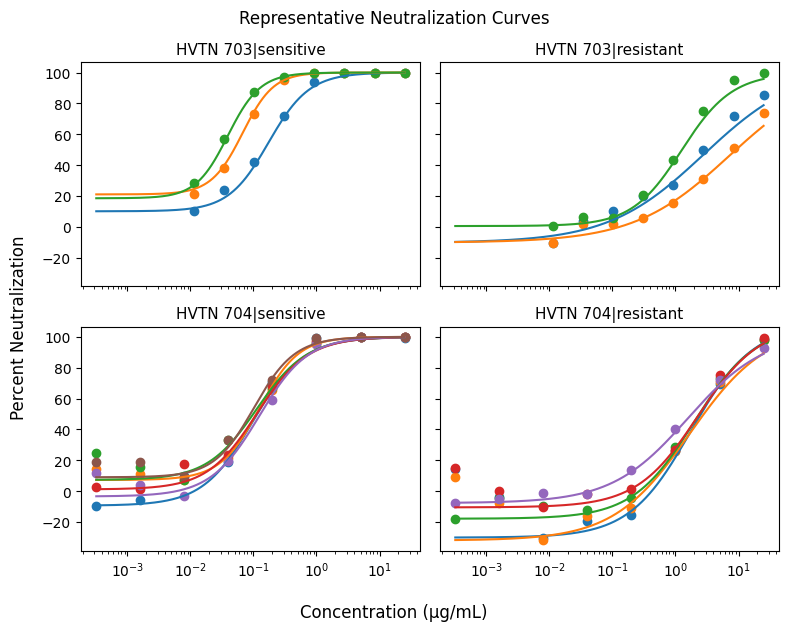

In [390]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)  # 2x2 grid

i = 0
param_cols = ['lower','upper','asymm','slope','inflection']
for protocol in ['HVTN 703','HVTN 704']:
    for pheno in ['sensitive','resistant']:
        ax = axes[i//2,i%2]
        ss = df.loc[(df.protocol==protocol) & (df.phenotype==pheno)]
        for j, row in ss.reset_index(drop=True).iterrows():
            t = atlas.loc[atlas.isolate==row.PLASMID_NAME].reset_index()
            if len(t) > 0:
                betas = t[param_cols].iloc[0]
                y = fivepl(xx, betas)
                ax.scatter(t.dilution, 100*t.pct_neutralization, label=row.PLASMID_NAME)
                ax.plot(xx, y)
        # ax.legend()
        ax.set_xscale("log")
        ax.set_title(f"{protocol}|{pheno}", fontsize=11)
        i += 1

fig.supxlabel("Concentration (μg/mL)")
fig.supylabel("Percent Neutralization")

plt.tight_layout()
plt.suptitle("Representative Neutralization Curves", y=1.03)
plt.show()